<hr/>
<h1>7. Model Evaluation And Deployment</h1>

<p>In this section, I will be evaluating the Models that I have trained and subsequently make a decision on which Model I will be Deploying to predict the next 60 Months of data. I will be evaluating the Models based on their Performance Metrics and also against the Baseline Model.</p>

<hr/>
<h2>7.2 Model Evaluation</h2>

<p>I will be using the Performance Metrics such as R2 to measure the effectiveness and accuracy of the model. This will then be placed in comparison to the Baseline model to ensure that all the model produced accurate and reliable results compared to the default ARIMA. There may also be the possibility of me using different models for different variable as different model may be more robust when dealing with other variables.</p>

In [161]:
# ----------- Ensure 'Model' Column Exists ----------- #
baseline_error_df["Model"] = "Baseline Model"
arima_error_df["Model"] = "ARIMA"
sarimax_error_df["Model"] = "SARIMAX"

# Align column names to match
arima_error_df.rename(columns={"ARIMA Order": "Order"}, inplace=True)
sarimax_error_df.rename(columns={"SARIMAX Order": "Order"}, inplace=True)
baseline_error_df.rename(columns={"ARIMA Order": "Order"}, inplace=True)

# Concatenating DataFrames
combined_df = pd.concat([baseline_error_df, arima_error_df, sarimax_error_df], ignore_index=True)

# Set 'Model' as the index
combined_df.set_index("Model", inplace=True)

combined_df

,Variable,Order,MAE,RMSE,R2 Score,Explained Variance Score,MAPE
Model,,,,,,,
Baseline Model,Gas Consumption (tons),"(1, 1, 0)",2.954328,3.652395,-0.229976,-0.000398,0.122795
Baseline Model,Electricity Consumption (MWh),"(1, 1, 0)",197.827313,218.059507,-4.004529,-0.002740,0.201997
Baseline Model,Water Consumption (tons),"(1, 1, 0)",100.947112,121.437014,-0.413446,-0.000753,0.205248
ARIMA,Gas Consumption (tons),"(18, 2, 9)",2.688515,3.307355,-0.008562,0.105145,0.101671
ARIMA,Electricity Consumption (MWh),"(8, 1, 8)",36.697694,46.072159,0.776596,0.779166,0.034733
ARIMA,Water Consumption (tons),"(9, 1, 17)",77.724024,101.403891,0.014433,0.015053,0.179988
SARIMAX,Gas Consumption (tons),"((5, 0, 3), (9, 1, 6, 12))",3.904889,4.674279,-1.014514,0.018138,0.142284
SARIMAX,Electricity Consumption (MWh),"((3, 1, 4), (5, 1, 6, 12))",28.479077,39.064938,0.839385,0.855936,0.026516
SARIMAX,Water Consumption (tons),"((2, 0, 1), (9, 1, 6, 12))",79.174317,103.453577,-0.025812,0.055082,0.171447


<p>With reference to the Outpit of the DataFrame above, I am able to see that generally, the models have performed better than the baseline model. However, I will only be using one model for each of the variable.</p>

<hr/>
<h2>7.3 Model Selection</h2>

<p>In this sub-section, I will be selecting the best performing model for each of the Variable for deployment. Each variable will perform better on a different model as each variable has different context such as seasons. The best model for each of the variable are indicated in the cell below.</p>

In [165]:
sorted_combined_df = combined_df.sort_values(by=["Variable", "R2 Score"], ascending=[True, False])

sorted_combined_df

,Variable,Order,MAE,RMSE,R2 Score,Explained Variance Score,MAPE
Model,,,,,,,
SARIMAX,Electricity Consumption (MWh),"((3, 1, 4), (5, 1, 6, 12))",28.479077,39.064938,0.839385,0.855936,0.026516
ARIMA,Electricity Consumption (MWh),"(8, 1, 8)",36.697694,46.072159,0.776596,0.779166,0.034733
Baseline Model,Electricity Consumption (MWh),"(1, 1, 0)",197.827313,218.059507,-4.004529,-0.002740,0.201997
ARIMA,Gas Consumption (tons),"(18, 2, 9)",2.688515,3.307355,-0.008562,0.105145,0.101671
Baseline Model,Gas Consumption (tons),"(1, 1, 0)",2.954328,3.652395,-0.229976,-0.000398,0.122795
SARIMAX,Gas Consumption (tons),"((5, 0, 3), (9, 1, 6, 12))",3.904889,4.674279,-1.014514,0.018138,0.142284
ARIMA,Water Consumption (tons),"(9, 1, 17)",77.724024,101.403891,0.014433,0.015053,0.179988
SARIMAX,Water Consumption (tons),"((2, 0, 1), (9, 1, 6, 12))",79.174317,103.453577,-0.025812,0.055082,0.171447
Baseline Model,Water Consumption (tons),"(1, 1, 0)",100.947112,121.437014,-0.413446,-0.000753,0.205248


<p>With reference to the output of the DataFrame above, I will be subsequently deploying the models indicated to predict the variable for the next 60 months.</p>

<hr/>
<h2>7.4 Model Deployment</h2>

<p>In this sub-section, I will be deploying the best model for each variable to predict the variable for the next 60 months. The accuracy may vary but the trend should generally be accurate for real life context and interpretation. The deployment will be done in the cell below for each of the Variable.</p>


Training and forecasting for **Gas Consumption (tons)** using **ARIMA**...

--- Model Summary for Gas Consumption (tons) ---
                                 SARIMAX Results                                  
Dep. Variable:     Gas Consumption (tons)   No. Observations:                  396
Model:                    ARIMA(18, 2, 9)   Log Likelihood                 201.573
Date:                    Fri, 14 Feb 2025   AIC                           -347.146
Time:                            22:52:16   BIC                           -235.809
Sample:                                 0   HQIC                          -303.029
                                    - 396                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2956      4.399     -0.295      0.7

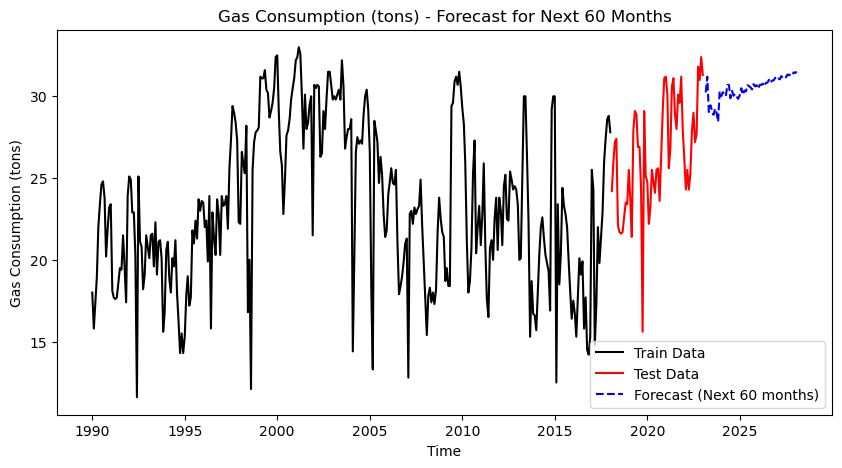


Training and forecasting for **Electricity Consumption (MWh)** using **SARIMAX**...

--- Model Summary for Electricity Consumption (MWh) ---
                                              SARIMAX Results                                              
Dep. Variable:                       Electricity Consumption (MWh)   No. Observations:                  396
Model:             SARIMAX(3, 1, 4)x(5, 1, [1, 2, 3, 4, 5, 6], 12)   Log Likelihood                 801.401
Date:                                             Fri, 14 Feb 2025   AIC                          -1564.802
Time:                                                     22:54:10   BIC                          -1489.789
Sample:                                                          0   HQIC                         -1535.046
                                                             - 396                                         
Covariance Type:                                               opg                                    

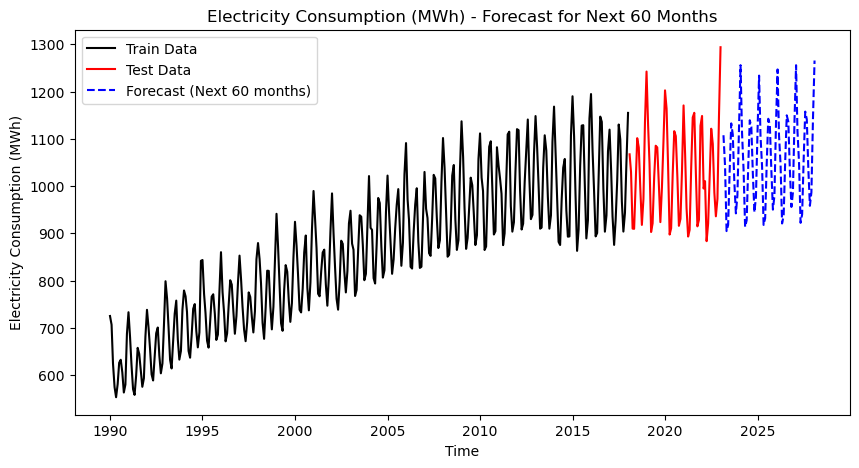


Training and forecasting for **Water Consumption (tons)** using **ARIMA**...

--- Model Summary for Water Consumption (tons) ---
                                  SARIMAX Results                                   
Dep. Variable:     Water Consumption (tons)   No. Observations:                  396
Model:                      ARIMA(9, 2, 17)   Log Likelihood                   3.182
Date:                      Fri, 14 Feb 2025   AIC                             47.637
Time:                              22:54:15   BIC                            154.998
Sample:                                   0   HQIC                            90.179
                                      - 396                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6806      0.354

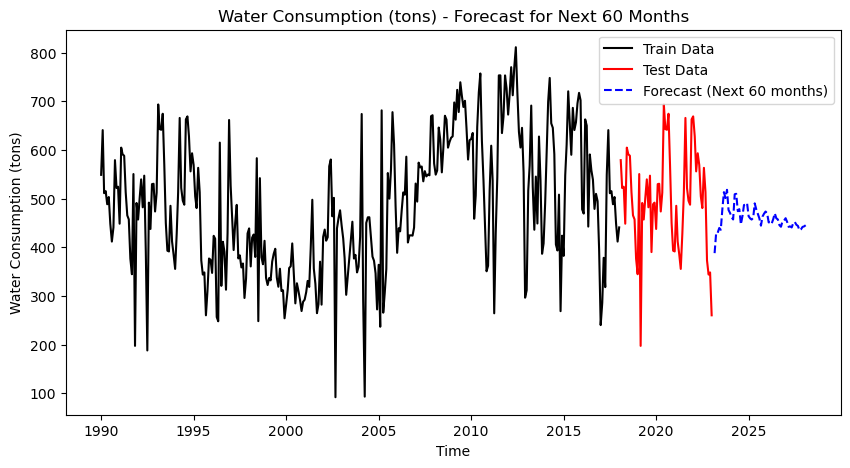

,Mean Forecast,Min Forecast,Max Forecast
Gas Consumption (tons),30.50,28.44,31.51
Electricity Consumption (MWh),1055.06,904.81,1265.85
Water Consumption (tons),460.42,387.92,518.04


In [215]:
# ----------- Define The Best Models For Each Variable ----------- #
best_models = {
    "Gas Consumption (tons)": ("ARIMA", (18, 2, 9)),
    "Electricity Consumption (MWh)": ("SARIMAX", ((3, 1, 4), (5, 1, 6, 12))),
    "Water Consumption (tons)": ("ARIMA", (9, 2, 17))
}

# ----------- Define The Forecast Period ----------- #
forecast_steps = 60

# ----------- Dictionary To Store Predictions ----------- #
future_forecasts = {}

# ----------- Dictionary To Store Summary Statistics ----------- #
forecast_summary = {}

# ----------- Defining Folder ----------- #
save_folder = "../models"
os.makedirs(save_folder, exist_ok=True)

# ----------- Loop Through Each Variable And Train The Best Model ----------- #
for variable, (model_type, order) in best_models.items():
    print(f"\nTraining and forecasting for **{variable}** using **{model_type}**...")

    # Fit The Best Model Using The Full Dataset (train + test) #
    full_data_log = pd.concat([train_log[variable], test_log[variable]])

    if model_type == "ARIMA":
        model = ARIMA(full_data_log, order=order)
    elif model_type == "SARIMAX":
        model = SARIMAX(full_data_log, order=order[0], seasonal_order=order[1])

    model_fit = model.fit()

    # Print Model Summary #
    print(f"\n--- Model Summary for {variable} ---")
    print(model_fit.summary())

    # Save The Model #
    model_filename = os.path.join(save_folder, f"{variable.replace(' ', '_')}_best_model.pkl")
    joblib.dump(model_fit, model_filename)
    print(f"Model saved as: {model_filename}")

    # Forecast The Next 60 Months After The Test Data #
    forecast_log = model_fit.forecast(steps=forecast_steps)

    # Reverse The log Transformation
    forecast = np.exp(forecast_log)

    # Store The Forecast
    future_forecasts[variable] = forecast

    # Store Forecast Summary Statistics #
    forecast_summary[variable] = {
        "Mean Forecast": round(forecast.mean(), 2),
        "Min Forecast": round(forecast.min(), 2),
        "Max Forecast": round(forecast.max(), 2),
    }

    # Create Future Index For Plotting #
    last_date = full_data_log.index[-1]
    future_dates = pd.date_range(start=last_date, periods=forecast_steps + 1, freq="M")[1:]

    # Plot Results With Full Dataset #
    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train[variable], label="Train Data", color="black")
    plt.plot(test.index, test[variable], label="Test Data", color="red")
    plt.plot(future_dates, forecast, label="Forecast (Next 60 months)", linestyle="dashed", color="blue")
    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.title(f"{variable} - Forecast for Next 60 Months")
    plt.legend()
    plt.show()

# ------------------ Display Forecast Summary ------------------ #
forecast_summary_df = pd.DataFrame.from_dict(forecast_summary, orient="index")

forecast_summary_df

<p>With reference to the Time-Series Output, I am able to see that the model have successfully been deployed to predict the variable's consumption in the next 60 months. This can be seen as the prediction is generally following the trend from the training data.</p>

<hr/>
<h2>7.6 Implications Of Deployment</h2>

<p>The possible implications of the predictions made are listed below.</p>
<br/>
<p><strong><u>Gas Consumption</u></strong></p>
<ul>
    <li>As Gas Consumption is predicted to continue rising, businesses relying on gas should be prepared to deal with increase prices. However, shifting to other source of energy may also be beneficial in reducing cost and also Gas Consumption.</li>
    <li>Environmental Concerns may rise due to the increase in Gas Consumptions. Therefore, Governments should implement policies or educate the public on limiting the usage of Gas so as to minimise Environmental Harm.</li>
    <li>Businesses which relies on Gas may need to have multiple supply chains due to the volatility especially if Gas Consumptions continue to rise.</li>
</ul>
<p><strong><u>Energy Consumption</u></strong></p>
<ul>
    <li>As Energy Consumption is predicted to continue rising, households may face higher utility bill which will increase the cost of living for families. Therefore, families should plan ahead and try to save as much energy as possible such as turning off lights during daytime, so as to limit the utility bill.</li>
    <li>Environmental Concerns may rise due to the increase in Energy Consumptions. Therefore, businesses should switch to renewable energy souces such as Solar Enrgy or Wind Energy so as to adopt sustainability into their framework.</li>
    <li>The Government may have to increase maintenance and mordernisations on present power grids so as to keep up with the demand of Energy Consumptions..</li>
</ul>
<p><strong><u>Water Consumption</u></strong></p>
<ul>
    <li>As Water Consumption is predicted to rise and subsequently fluctuate and drop by a small margin, families should be prepared for rising utilities bill or even the unpredictability in the bills due to changing demands.</li>
    <li>Governments may have to adopt new methods and ways to keep up with the fluctuating demand of Water and may have to be prepared for unpredictable events which may results due to stress on Water Sources such as droughts and water shortage.</li>
</ul>
<br/>
<p>With the Implications listed, I hereby conclude the AIML CA2, Task A, Time Series.</p>